In [105]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import math as m
import pyspark.sql.functions as F

# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

**Outlier Detection Function**

In [106]:
# Outlier detection and treatment using IQR altered from https://www.machinelearningplus.com/pyspark/pyspark-outlier-detection-and-treatment/ to handle large datasets
def iqr_outlier_treatment(dataframe, columns, n):
    """
    Detects and treats outliers using IQR for multiple variables in a PySpark DataFrame.
    :param dataframe: The input PySpark DataFrame
    :param columns: A list of columns to apply IQR outlier treatment
    :param factor: The IQR factor to use for detecting outliers (default is 1.5)
    :return: The processed DataFrame with outliers treated
    """
    factor = m.sqrt(np.log(n)) - 0.5  # Adjust the factor based on the number of standard deviations
    for column in columns:
        # Calculate Q1, Q3, and IQR
        quantiles = dataframe.approxQuantile(column, [0.25, 0.75], 0.01)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        # Define the upper and lower bounds for outliers
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        # Filter outliers and update the DataFrame
        dataframe = dataframe.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))
    return dataframe

**Creating the Training(Analysis) Data**

In [107]:
sdf_2024_green = spark.read.parquet("../taxi_data/green/2024")

sdf_2024_green = sdf_2024_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2024_yellow = spark.read.parquet("../taxi_data/yellow/2024")

sdf_2024_yellow = sdf_2024_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

In [108]:
sdf_2023_green = spark.read.parquet("../taxi_data/green/2023")

sdf_2023_green = sdf_2023_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2023_yellow = spark.read.parquet("../taxi_data/yellow/2023")

sdf_2023_yellow = sdf_2023_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")


In [109]:
sdf_2024 = sdf_2024_green.unionByName(sdf_2024_yellow, allowMissingColumns=True)
sdf_2024.count()

41829938

In [110]:
sdf_2023 = sdf_2023_green.unionByName(sdf_2023_yellow, allowMissingColumns=True)
sdf_2023.count()

15610024

In [111]:
# Read the irregular data for 2023 and 2024 in the month of October and removed all the rows with null pickup and dropoff datetimes
temp = spark.read.parquet("../taxi_data/irregular")

temp = temp.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

temp_work = temp.filter(F.col("pickup_datetime").isNotNull() & F.col("dropoff_datetime").isNotNull()) \
    .filter(F.col("pickup_datetime") < F.col("dropoff_datetime"))

sdf_2023 = sdf_2023.unionByName(temp_work, allowMissingColumns=True)

sdf_2023.count()

15676112

In [112]:
sdf_train = sdf_2023.unionByName(sdf_2024, allowMissingColumns=True)
sdf_train.count()

57506050

In [113]:
sdf_train.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|       1|2023-09-01 00:08:04|2023-09-01 00:13:39|          41|          75|          1.1|        7.9|       0.0|        10.4|                 0.0|
|       1|2023-09-01 00:30:44|2023-09-01 00:39:30|          74|         236|          1.8|       10.7|      3.15|        19.1|                2.75|
|       2|2023-09-01 00:14:39|2023-09-01 00:38:30|          93|         205|        10.52|       60.0|       0.0|        61.0|                 0.0|
|       2|2023-09-01 00:35:48|2023-09-01 00:56:48|         112|          17|         4.72|       23.3|      10.0

**Creating Test Data**

In [114]:
sdf_2025_green = spark.read.parquet("../taxi_data/green/2025")

sdf_2025_green = sdf_2025_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

sdf_2025_yellow = spark.read.parquet("../taxi_data/yellow/2025")

sdf_2025_yellow = sdf_2025_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

In [115]:
sdf_2025 = sdf_2025_green.unionByName(sdf_2025_yellow, allowMissingColumns=True)
sdf_2025.count()

24386791

**Preprocessing for Train Data**

In [ ]:
# Calculate travel time in seconds
sdf_train = sdf_train.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_train_filtered = sdf_train.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_train_filtered = sdf_train_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
from pyspark.sql.functions import col,isnan, when, count
sdf_train_filtered.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in sdf_train_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_train_filtered_outlier = iqr_outlier_treatment(sdf_train_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_train_filtered.count())

# adding a date column for each trip and removing the unnecessary columns
split_col1 = F.split(sdf_train_filtered_outlier['pickup_datetime'], ' ')
sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn('date', split_col1.getItem(0)).orderBy("date", ascending=True)
sdf_train_filtered_outlier = sdf_train_filtered_outlier.filter((F.col("date") >= "2023-07-01") & (F.col("date") <= "2024-12-31"))
sdf_train_filtered_outlier = sdf_train_filtered_outlier.drop("pickup_datetime", "dropoff_datetime", "PULocationID")

sdf_train_filtered_outlier.show(10)

+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|VendorID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|
+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|       2|         170|         3.45|       17.0|      4.45|        26.7|                2.75|                798|2023-07-01|
|       1|         263|          1.8|       12.1|       5.1|        22.2|                 2.5|                616|2023-07-01|
|       2|         262|         1.49|       10.0|      3.05|        18.3|                2.75|                434|2023-07-01|
|       2|         163|         2.31|       19.1|       0.0|        24.1|                 2.5|               1219|2023-07-01|
|       2|          75|         9.32|       38.0|       0.0|       43.25|                2.75|               1268|2023

In [117]:
sdf_train_filtered_outlier.count()

39642532

In [118]:
# average new york taxi speed according to https://medium.com/@jiaminhan/looking-through-the-taxi-meter-analysis-of-the-nyc-green-taxi-data-c1dbe5619afe
average_speed = 14 / 3600 # in miles per second

# average time spent in traffic  per day in new york according to https://congestionreliefzone.mta.info/about
average_time_in_traffic = m.floor((117/365) * 3600) # in seconds

# tolerance time for congestion time
tolerance = 120

sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) >= tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

In [119]:
sdf_train_filtered_outlier.orderBy("congestion_time_seconds", ascending=False).show(10)

+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|VendorID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|congestion_time_seconds|
+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|       2|         230|         1.06|        6.5|       0.0|        11.5|                 2.5|               4429|2024-08-22|      4156.428571428572|
|       2|         158|         1.05|       63.9|     15.47|       92.81|                 2.5|               4426|2023-09-08|                 4156.0|
|       1|          61|          1.1|       28.5|       0.0|        29.0|                 0.0|               4430|2024-10-21|      4147.142857142857|
|       2|         132|         1.08|       70.0|     25.03|      108.47|                 0.0|      

In [120]:
# filtering out rows where congestion time is less than 0 to find trips that were in congestion
final_filtered_df = sdf_train_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_df.count()

26028146

**Preprocessing for Test Data**

In [121]:
# Calculate travel time in seconds
sdf_2025 = sdf_2025.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_2025_filtered = sdf_2025.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_2025_filtered = sdf_2025_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_2025_filtered_outlier = iqr_outlier_treatment(sdf_2025_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_2025_filtered.count())

# adding a date column for each trip and removing the unnecessary columns
split_col2 = F.split(sdf_2025_filtered_outlier['pickup_datetime'], ' ')
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn('date', split_col2.getItem(0)).orderBy("date", ascending=True)
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.filter((F.col("date") >= "2025-01-01") & (F.col("date") <= "2025-06-30"))
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.drop("pickup_datetime", "dropoff_datetime", "PULocationID")

sdf_2025_filtered_outlier.show(10)

+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|VendorID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|
+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|       2|         235|         5.93|       24.7|       6.8|        34.0|                 0.0|                851|2025-01-01|
|       2|          48|         3.88|       6.02|       0.0|       10.02|                 0.0|               2214|2025-01-01|
|       1|         237|          1.6|       10.0|       3.0|        18.0|                 2.5|                501|2025-01-01|
|       2|          50|         3.07|      13.95|       0.0|       17.95|                 0.0|               1988|2025-01-01|
|       2|          75|         1.32|        8.6|       0.0|        11.1|                 0.0|                353|2025

In [122]:
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

VendorID,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,congestion_surcharge,travel_time_seconds
0,0,0,0,0,0,0,0,0


In [123]:
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) >= tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

sdf_2025_filtered_outlier.show(10)

+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|VendorID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|congestion_time_seconds|
+--------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|       2|         235|         5.93|       24.7|       6.8|        34.0|                 0.0|                851|2025-01-01|                    0.0|
|       2|          48|         3.88|       6.02|       0.0|       10.02|                 0.0|               2214|2025-01-01|     1216.2857142857142|
|       1|         237|          1.6|       10.0|       3.0|        18.0|                 2.5|                501|2025-01-01|                    0.0|
|       2|          50|         3.07|      13.95|       0.0|       17.95|                 0.0|      

In [124]:
final_filtered_testdf = sdf_2025_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_testdf.count()

10323231

**Data Analysis**

In [125]:
from pyspark.sql import functions as F
# Calculate median congestion time and total trips for each DOLocationID
# median used because of obvious skewness in the data (see histogram below)
congestion_groupby = final_filtered_df.groupBy("DOLocationID").agg(F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.count("DOLocationID").alias("total_trips"))

congestion_groupby.orderBy("median_congestion_time_seconds", ascending=False).show(10)


+------------+------------------------------+-----------+
|DOLocationID|median_congestion_time_seconds|total_trips|
+------------+------------------------------+-----------+
|         204|            2151.5714285714284|          1|
|         105|             952.8571428571428|          9|
|         156|             866.5714285714284|          3|
|          46|             837.1428571428573|         57|
|         214|             749.5714285714284|         15|
|           5|             743.5714285714284|          4|
|         222|             724.2857142857142|       2618|
|          55|             673.2857142857142|       2594|
|          26|             644.1428571428571|       4075|
|          27|             643.8571428571429|         34|
+------------+------------------------------+-----------+
only showing top 10 rows



In [126]:
# add a column to the dataframe
sum_total_trips = congestion_groupby.select(F.sum("total_trips").alias("sum_total_trips")).collect()[0]["sum_total_trips"]

congestion_groupby = congestion_groupby.withColumn("proportion_of_congestion_time",\
    F.col("median_congestion_time_seconds") * (F.col("total_trips") / sum_total_trips))

congestion_groupby = congestion_groupby.withColumnRenamed("DOLocationID", "LocationID")
congestion_groupby.orderBy("proportion_of_congestion_time", ascending=False).show(10)

# This shows LocationID 161 (Manhattan,Midtown Center) has the highest proportion of congestion time in NYC taxi rides in 2023 and 2024

+----------+------------------------------+-----------+-----------------------------+
|LocationID|median_congestion_time_seconds|total_trips|proportion_of_congestion_time|
+----------+------------------------------+-----------+-----------------------------+
|       161|             483.1428571428571|    1088635|           20.207594666393614|
|       230|             537.7142857142857|     849829|            17.55657870192851|
|       237|             366.2857142857142|    1074459|              15.120515394593|
|       236|             328.1428571428571|    1094226|           13.795160285331116|
|       170|             410.8571428571429|     805392|           12.713201163079384|
|       163|             445.7142857142857|     741929|           12.705029174406594|
|       162|             420.1428571428571|     782172|           12.625715979046022|
|        48|             451.2857142857143|     679090|           11.774315992936483|
|       186|             457.8571428571429|     667946

**GeoVisualization**

In [127]:
import geopandas as gpd

# Load the shapefile (use the .shp file as entry point)
sf = gpd.read_file("../taxi_data/taxi_zones/taxi_zones.shp")
sf.head()

# Convert the geometry shape to to latitude and longitude
# Please attribute this if you are using it
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")
sf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [128]:
zones = pd.read_csv("../taxi_data/taxi_zones/taxi_zone_lookup.csv")
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [129]:
zones_df = gpd.GeoDataFrame(
    pd.merge(zones, sf, on='LocationID', how='inner')
)
zones_df.head()


,LocationID,Borough,Zone,service_zone,OBJECTID,Shape_Leng,Shape_Area,zone,borough,geometry
0,1,EWR,Newark Airport,EWR,1,0.116357,0.000782,Newark Airport,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,Queens,Jamaica Bay,Boro Zone,2,0.433470,0.004866,Jamaica Bay,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone,3,0.084341,0.000314,Allerton/Pelham Gardens,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,Manhattan,Alphabet City,Yellow Zone,4,0.043567,0.000112,Alphabet City,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,Staten Island,Arden Heights,Boro Zone,5,0.092146,0.000498,Arden Heights,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [130]:
congestion_groupby_pd = congestion_groupby.toPandas()
congestion_geodata = congestion_groupby_pd.merge(zones_df[['LocationID', 'geometry']], on='LocationID', how='inner')
congestion_geodata.head()

,LocationID,median_congestion_time_seconds,total_trips,proportion_of_congestion_time,geometry
0,148,404.142857,340937,5.293779,"POLYGON ((-73.98448 40.72023, -73.98507 40.719..."
1,243,407.142857,14256,0.222998,"POLYGON ((-73.93157 40.86958, -73.93141 40.868..."
2,31,468.571429,286,0.005149,"POLYGON ((-73.87094 40.85727, -73.87094 40.857..."
3,85,556.428571,4816,0.102956,"POLYGON ((-73.94716 40.65559, -73.94703 40.654..."
4,137,357.000000,332033,4.554138,"POLYGON ((-73.9722 40.7404, -73.97222 40.74031..."


In [131]:
# create a JSON 
geoJSON = zones_df[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()

In [132]:
import folium

map_1 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_1.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','median_congestion_time_seconds'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Median Congestion Time (seconds)'
))

map_1.save('../plots/foliumChoroplethMap1.html')

map_2 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_2.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','proportion_of_congestion_time'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Proportion of Congestion Time'\
))

map_2.save('../plots/foliumChoroplethMap2.html')

In [133]:
# so that visualization is much smaller
final_filtered_df_pd = final_filtered_df.sample(fraction=0.2, seed=23).toPandas()

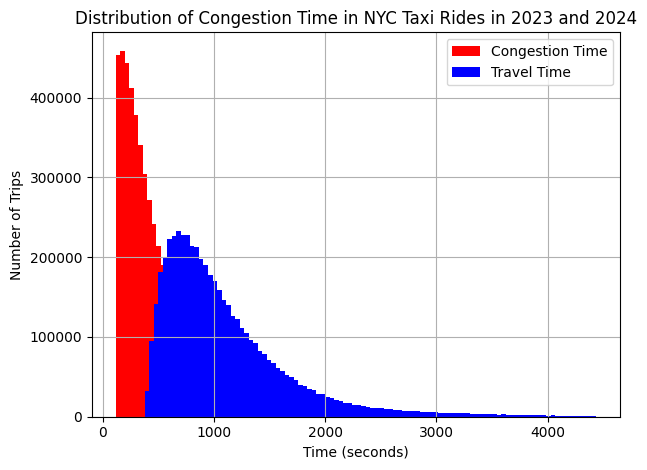

In [134]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
final_filtered_df_pd['congestion_time_seconds'].hist(ax=ax, bins = 100, color='red')
final_filtered_df_pd['travel_time_seconds'].hist(ax=ax, bins = 100, color='blue')
xlabel = "Time (seconds)"
ax.set_xlabel(xlabel)
ylabel = "Number of Trips"
ax.set_ylabel(ylabel)
title = "Distribution of Congestion Time in NYC Taxi Rides in 2023 and 2024"
ax.set_title(title)
ax.legend(['Congestion Time', 'Travel Time'])
plt.tight_layout()  
plt.show()

**Time Series Analysis**

In [163]:
dategroup_traindf = final_filtered_df.groupBy("DOLocationID", "date").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount")).orderBy("DOLocationID", "date")

dategroup_traindf.count()

112830

In [164]:
dategroup_testdf = final_filtered_testdf.groupBy("DOLocationID", "date").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount")).orderBy("DOLocationID", "date")

dategroup_testdf.count()

39835

In [165]:
dategroup_testdf.show(10)

+------------+----------+----------+------------------------------+------------------+---------------------------+-------------------+---------------------+-----------------+----------------+------------+----------------+
|DOLocationID|      date|trip_count|median_congestion_time_seconds|  daily_congestion|average_travel_time_seconds|total_trip_distance|average_trip_distance|total_fare_amount|total_tip_amount|total_amount|avg_total_amount|
+------------+----------+----------+------------------------------+------------------+---------------------------+-------------------+---------------------+-----------------+----------------+------------+----------------+
|           1|2025-01-02|         2|             1819.142857142857|            3704.0|                     2302.0|                3.5|                 1.75|           160.79|             0.0|      190.55|          95.275|
|           1|2025-01-04|         2|            1655.4285714285716|3432.4285714285716|                     2140.

In [166]:
# convert to pandas df for visualizations
dategroup_traindf_pd = dategroup_traindf.toPandas()
dategroup_testdf_pd = dategroup_testdf.toPandas()

dategroup_traindf_pd.shape, dategroup_testdf_pd.shape

((112830, 12), (39835, 12))

In [167]:
# this list contrains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024 and 2 random ones
unique_ids = [161, 230, 237, 236, 170, 163, 123, 17]

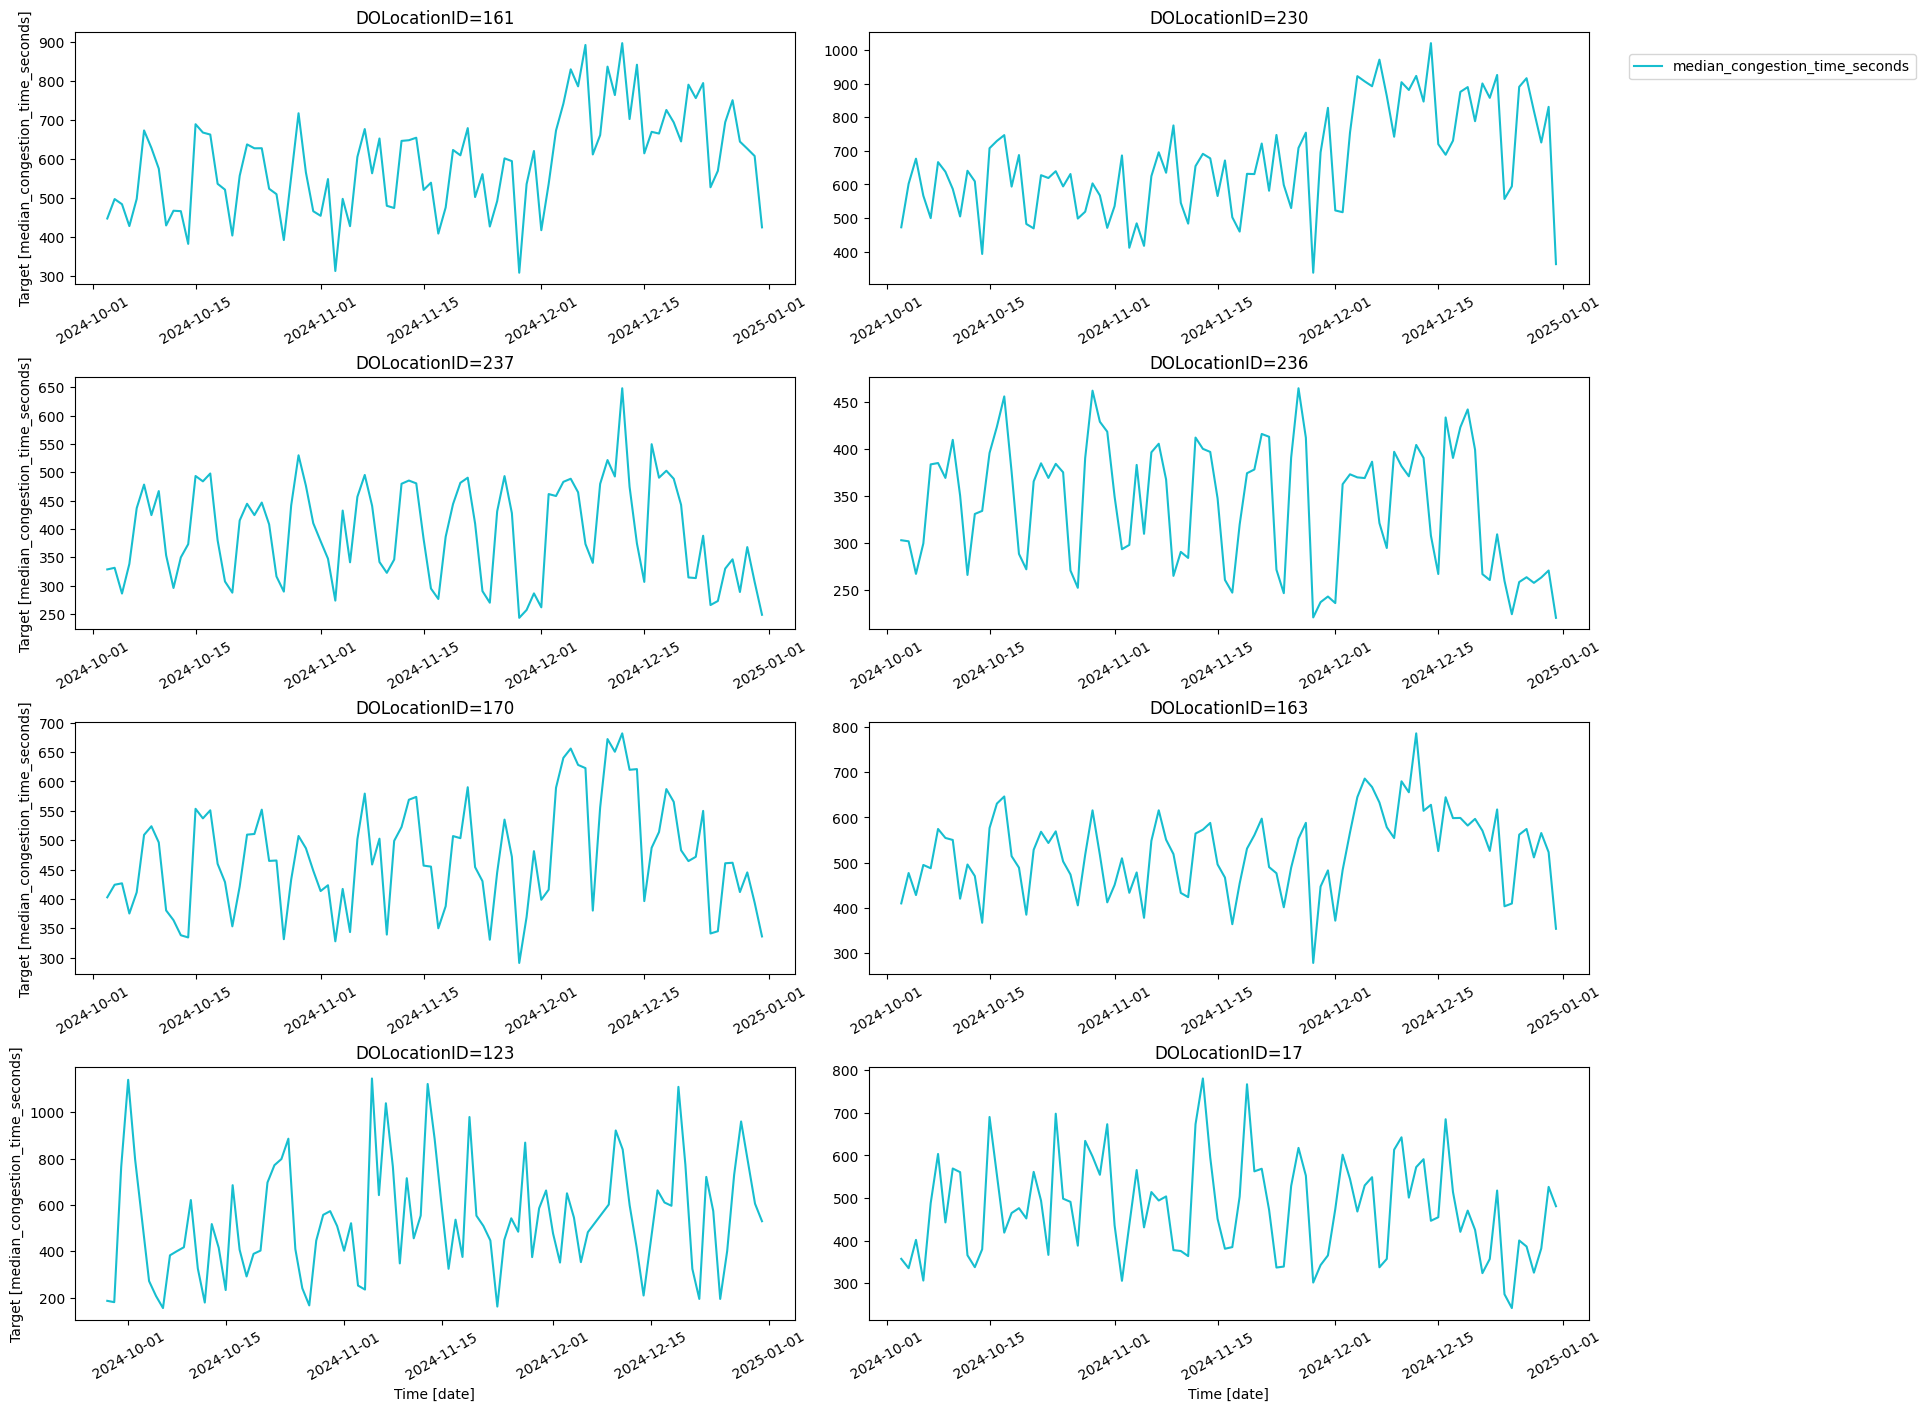

In [168]:
from utilsforecast.plotting import plot_series
dategroup_traindf_pd["date"] = pd.to_datetime(dategroup_traindf_pd["date"])
plot_series(
            df=dategroup_traindf_pd,
            ids =unique_ids, 
            time_col='date',
            target_col='median_congestion_time_seconds',
            id_col="DOLocationID",
            max_insample_length=90)

# max_insample_length = 500
# This is about 3-4 days of data for the LocationIDs in the unique_ids list 
# max_insample_length = 5000
# This would be about 30-40 days of data for the LocationIDs in the unique_ids list so around a month of data


In [169]:
dategroup_traindf_pd.head(10)

,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
0,1,2023-07-01,4,613.714286,3368.000000,4032.500000,49.63,12.407500,397.90,98.32,561.67,140.4175
1,1,2023-07-06,2,160.285714,3052.142857,3872.500000,18.25,9.125000,112.44,15.43,148.87,74.4350
2,1,2023-07-07,2,344.714286,2295.714286,3889.000000,21.32,10.660000,175.50,31.73,236.73,118.3650
3,1,2023-07-09,1,3668.285714,3668.285714,4036.000000,1.43,1.430000,7.90,0.00,11.90,11.9000
4,1,2023-07-10,1,781.000000,781.000000,1501.000000,2.80,2.800000,46.10,0.00,67.40,67.4000
5,1,2023-07-11,4,284.714286,2856.714286,4073.750000,52.26,13.065000,372.70,72.85,496.30,124.0750
6,1,2023-07-12,3,520.142857,1928.857143,3608.666667,34.60,11.533333,244.87,52.00,351.72,117.2400
7,1,2023-07-15,1,574.142857,574.142857,4295.000000,14.47,14.470000,104.90,24.13,144.78,144.7800
8,1,2023-07-18,2,228.000000,768.142857,3882.500000,27.21,13.605000,144.51,7.59,186.10,93.0500
9,1,2023-07-20,4,613.714286,2904.571429,3605.500000,44.79,11.197500,271.15,12.24,348.39,87.0975


**Training Linear Regression Model**

In [171]:
# training only on the LocationIDs in the unique_ids list because the data is too large to train on all the LocationIDs
# this list contrains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024 and 2 random ones
train_data_subset = dategroup_traindf_pd[dategroup_traindf_pd["DOLocationID"].isin(unique_ids)]
test_data_subset = dategroup_testdf_pd[dategroup_testdf_pd["DOLocationID"].isin(unique_ids)]
train_data_subset.loc[:, "date"] = pd.to_datetime(train_data_subset["date"])
test_data_subset.loc[:, "date"] = pd.to_datetime(test_data_subset["date"])
train_data_subset.shape, test_data_subset.shape

((4309, 12), (1447, 12))

In [156]:
from sklearn.model_selection import train_test_split

# because lasso requires data entries for each ID to be greater than 1
#counts = train_data_subset["DOLocationID"].value_counts()
#valid_ids = counts[counts >= 2].index

train_data, validation_data = train_test_split(train_data_subset, train_size=0.8, random_state=23)#,stratify=train_data_subset["DOLocationID"].isin(valid_ids))
train_data_x = train_data.drop(columns=["median_congestion_time_seconds"])
train_data_y = train_data["median_congestion_time_seconds"]
validation_data_x = validation_data.drop(columns=["median_congestion_time_seconds"])
validation_data_y = validation_data["median_congestion_time_seconds"]
test_data_x = test_data_subset.drop(columns=["median_congestion_time_seconds"])
test_data_y = test_data_subset["median_congestion_time_seconds"]
train_data_full_x = train_data_subset.drop(columns=["median_congestion_time_seconds"])
train_data_full_y = train_data_subset["median_congestion_time_seconds"]

In [144]:
train_data

,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
27032,237,2023-11-20,2565,466.428571,1.343565e+06,996.046784,4710.59,1.836487,40289.49,8149.04,60772.60,23.693021
76932,170,2024-07-07,694,322.428571,2.579714e+05,820.786744,1211.99,1.746383,9559.75,1723.00,14213.00,20.479827
11720,230,2023-08-27,1030,338.571429,4.394967e+05,1007.843689,2327.82,2.260019,17245.87,2524.93,24248.45,23.542184
59069,230,2024-03-18,1309,381.285714,5.908246e+05,1015.129106,2869.92,2.192452,21847.86,4190.79,32964.99,25.183338
23277,170,2023-10-20,7,719.000000,5.846571e+03,1986.857143,31.35,4.478571,203.76,29.91,273.36,39.051429
...,...,...,...,...,...,...,...,...,...,...,...,...
38258,237,2023-12-03,1670,309.285714,6.546511e+05,908.592814,3354.94,2.008946,25344.62,4890.81,37189.00,22.268862
79376,230,2024-07-25,1856,623.285714,1.292446e+06,1362.103448,4805.18,2.588998,39535.96,6312.42,56308.32,30.338534
51035,17,2024-03-24,55,439.571429,3.082200e+04,1801.418182,265.44,4.826182,1588.62,219.64,2000.64,36.375273
26957,236,2023-11-27,2419,345.857143,9.942814e+05,951.150062,5081.03,2.100467,38128.14,7702.04,57592.39,23.808346


In [145]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import root_mean_squared_error, r2_score

In [146]:
# Identify categorical and numeric columns
cat_cols = ["date", "DOLocationID"] 
num_cols = [c for c in train_data.drop(columns=["median_congestion_time_seconds"]).columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [88]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(cv=10, random_state=23))
])
lr_model.fit(train_data_x, train_data_y)

y_pred = lr_model.predict(validation_data_x)
print("R^2:", r2_score(validation_data_y, y_pred))
print("RMSE:", root_mean_squared_error(validation_data_y, y_pred))

R^2: 0.8641640209327351
RMSE: 78.25193467289274


In [89]:
# Baseline prediction = mean of training target
baseline_pred = np.full_like(validation_data_y, train_data_y.mean())

# Evaluate baseline
baseline_r2 = r2_score(validation_data_y, baseline_pred)
baseline_mse = root_mean_squared_error(validation_data_y, baseline_pred)

print("Baseline R^2:", baseline_r2)
print("Baseline RMSE:", baseline_mse)

Baseline R^2: -9.276121272883131e-06
Baseline RMSE: 212.31940539987713


In [90]:
lr_model.fit(train_data_full_x, train_data_full_y)

y_pred_full = lr_model.predict(test_data_x)
print("R^2:", r2_score(test_data_y, y_pred_full))
print("RMSE:", root_mean_squared_error(test_data_y, y_pred_full))

R^2: 0.8541255206543296
RMSE: 41.60949017871697


**Prediction for July Month for the list of LocationID's**

In [178]:
train_data_subset_j2d = train_data_subset[
    (train_data_subset["date"] >= pd.to_datetime("2023-07-01")) &
    (train_data_subset["date"] <= pd.to_datetime("2024-12-31"))
]
train_data_subset_j2d.sort_values(["date", "DOLocationID"]).reset_index(drop=True)
train_data_subset_j2d.head(20)

,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
5152,17,2023-07-01,23,260.285714,8065.000000,1371.173913,91.28,3.968696,551.58,87.10,714.68,31.073043
5153,17,2023-07-02,30,220.142857,9698.571429,1483.000000,135.30,4.510000,731.96,86.51,912.97,30.432333
5154,17,2023-07-03,18,292.857143,7216.857143,1663.222222,88.36,4.908889,500.40,66.62,633.52,35.195556
5155,17,2023-07-04,18,277.000000,7955.857143,1602.277778,81.22,4.512222,466.50,67.95,606.50,33.694444
5156,17,2023-07-05,37,535.285714,20572.857143,1983.513514,205.40,5.551351,1188.18,113.59,1481.82,40.049189
5157,17,2023-07-06,31,357.285714,15853.142857,1849.032258,161.26,5.201935,915.25,167.94,1231.69,39.731935
5158,17,2023-07-07,40,412.571429,17895.000000,1643.025000,185.99,4.649750,1112.53,189.05,1468.43,36.710750
5159,17,2023-07-08,39,323.714286,15853.857143,1974.025641,237.74,6.095897,1252.88,161.67,1582.40,40.574359
5160,17,2023-07-09,34,255.571429,11477.142857,1431.705882,144.67,4.255000,830.10,141.35,1083.45,31.866176
5161,17,2023-07-10,28,321.714286,12003.714286,1858.785714,155.72,5.561429,890.92,104.49,1119.41,39.978929


In [181]:
for lag in range (1, 8): # account for 7 days of lag for each day
    train_data_subset_j2d[f"median_congestion_lag{lag}"] = train_data_subset_j2d.groupby("DOLocationID")["median_congestion_time_seconds"].shift(lag)
    train_data_subset_j2d[f"average_travel_lag{lag}"] = train_data_subset_j2d.groupby("DOLocationID")["average_travel_time_seconds"].shift(lag)
    train_data_subset_j2d[f"average_tripd_lag{lag}"] = train_data_subset_j2d.groupby("DOLocationID")["average_trip_distance"].shift(lag)
    train_data_subset_j2d[f"average_total_amount_lag{lag}"] = train_data_subset_j2d.groupby("DOLocationID")["avg_total_amount"].shift(lag)

train_data_subset_j2d["daily_congestion_roll7"] = train_data_subset_j2d.groupby("DOLocationID")["daily_congestion"].shift(1).rolling(7).mean()
train_data_subset_j2d["total_trip_dist_roll7"] = train_data_subset_j2d.groupby("DOLocationID")["average_travel_time_seconds"].shift(1).rolling(7).mean()
train_data_subset_j2d["total_fare_roll7"] = train_data_subset_j2d.groupby("DOLocationID")["total_fare_amount"].shift(1).rolling(7).mean()
train_data_subset_j2d["total_tip_roll7"] = train_data_subset_j2d.groupby("DOLocationID")["total_tip_amount"].shift(1).rolling(7).mean()
train_data_subset_j2d["total_amount_roll7"] = train_data_subset_j2d.groupby("DOLocationID")["total_amount"].shift(1).rolling(7).mean()

**Evaluvating Prediction on 2023 and 2024 data**

In [ ]:
train_data, validation_data = train_test_split(train_data_subset_j2d, train_size=0.8, random_state=23)
train_data_x = train_data.drop(columns=["median_congestion_time_seconds"])
train_data_y = train_data["median_congestion_time_seconds"]
validation_data_x = validation_data.drop(columns=["median_congestion_time_seconds"])
validation_data_y = validation_data["median_congestion_time_seconds"]

In [184]:
lr_model.fit(train_data_x, train_data_y)

y_pred = lr_model.predict(validation_data_x)
print("R^2:", r2_score(validation_data_y, y_pred))
print("RMSE:", root_mean_squared_error(validation_data_y, y_pred))

R^2: 0.7744091148657604
RMSE: 82.53660695304488


In [185]:
# Baseline prediction = mean of training target
baseline_pred = np.full_like(validation_data_y, train_data_y.mean())

# Evaluate baseline
baseline_r2 = r2_score(validation_data_y, baseline_pred)
baseline_mse = root_mean_squared_error(validation_data_y, baseline_pred)

print("Baseline R^2:", baseline_r2)
print("Baseline RMSE:", baseline_mse)

Baseline R^2: -0.0005421353316064081
Baseline RMSE: 173.82151402193065


In [186]:
# extracting only june
test_data_subset_june24 = test_data_subset[
    (test_data_subset["date"] >= pd.to_datetime("2025-06-24")) &
    (test_data_subset["date"] <= pd.to_datetime("2025-06-30"))
]
test_data_subset_june24.sort_values(["date", "DOLocationID"]).reset_index(drop=True)
test_data_subset_june24.head(20)


,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
2105,17,2025-06-24 00:00:00,136,453.000000,7.992829e+04,1875.161765,680.92,5.006765,4267.92,362.67,5095.41,37.466250
2106,17,2025-06-25 00:00:00,132,516.857143,8.842443e+04,1952.674242,658.50,4.988636,4240.96,337.82,5042.72,38.202424
2107,17,2025-06-26 00:00:00,159,529.571429,1.007394e+05,1893.823899,779.25,4.900943,4952.91,381.20,5906.30,37.146541
2108,17,2025-06-27 00:00:00,107,366.857143,5.211600e+04,1604.411215,464.94,4.345234,2791.36,163.65,3289.89,30.746636
2109,17,2025-06-28 00:00:00,159,314.285714,6.178671e+04,1439.452830,649.78,4.086667,4102.66,288.06,4860.91,30.571761
2110,17,2025-06-29 00:00:00,170,315.571429,7.077486e+04,1445.847059,680.63,4.003706,4412.73,181.96,5056.43,29.743706
2111,17,2025-06-30 00:00:00,72,473.428571,4.101900e+04,1758.958333,332.99,4.624861,2092.81,133.08,2451.96,34.055000
17566,123,2025-06-24 00:00:00,25,414.857143,1.339429e+04,1410.160000,85.01,3.400400,553.70,0.00,584.20,23.368000
17567,123,2025-06-25 00:00:00,12,400.142857,7.109857e+03,1384.916667,36.98,3.081667,252.55,0.00,264.55,22.045833
17568,123,2025-06-26 00:00:00,21,758.857143,1.860286e+04,2346.666667,119.30,5.680952,630.57,5.00,675.70,32.176190


In [187]:
future_dates = pd.date_range(start="2025-07-01", end="2025-07-31")
future_index = pd.MultiIndex.from_product([future_dates, unique_ids], names=["date", "DOLocationID"])

# convert MultiIndex to a DataFrame
future_df = future_index.to_frame(index=False)

# add a placeholder column for your target
future_df["median_congestion_time_seconds"] = None

# sort based on LocationID and date so that rolling can respect the order of rows(each date) within each group
future_df = future_df.sort_values(["DOLocationID", "date"]).reset_index(drop=True)

future_df.head(10)

,date,DOLocationID,median_congestion_time_seconds
0,2025-07-01,17,None
1,2025-07-02,17,None
2,2025-07-03,17,None
3,2025-07-04,17,None
4,2025-07-05,17,None
5,2025-07-06,17,None
6,2025-07-07,17,None
7,2025-07-08,17,None
8,2025-07-09,17,None
9,2025-07-10,17,None


In [188]:
df_full = pd.concat([test_data_subset_june24, future_df], ignore_index=True)
df_full = df_full.sort_values(["DOLocationID", "date"]).reset_index(drop=True)
df_full.head()

/var/folders/qf/25308l_17hv3chqx70wpnbqm0000gn/T/ipykernel_5190/3607046803.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_full = pd.concat([test_data_subset_june24, future_df], ignore_index=True)


,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
0,17,2025-06-24 00:00:00,136.0,453.000000,79928.285714,1875.161765,680.92,5.006765,4267.92,362.67,5095.41,37.466250
1,17,2025-06-25 00:00:00,132.0,516.857143,88424.428571,1952.674242,658.50,4.988636,4240.96,337.82,5042.72,38.202424
2,17,2025-06-26 00:00:00,159.0,529.571429,100739.428571,1893.823899,779.25,4.900943,4952.91,381.20,5906.30,37.146541
3,17,2025-06-27 00:00:00,107.0,366.857143,52116.000000,1604.411215,464.94,4.345234,2791.36,163.65,3289.89,30.746636
4,17,2025-06-28 00:00:00,159.0,314.285714,61786.714286,1439.452830,649.78,4.086667,4102.66,288.06,4860.91,30.571761


In [ ]:
# predicting for July 2025 using the June 2025
np.random.seed(23)

df_full["date"] = pd.to_datetime(df_full["date"])
july_mask = df_full["date"] >= pd.Timestamp("2025-07-01")

for lag in range (1, 8): # account for 7 days of lag for each day
    df_full[f"median_congestion_lag{lag}"] = df_full.groupby("DOLocationID")["median_congestion_time_seconds"].shift(lag)
    df_full[f"average_travel_lag{lag}"] = df_full.groupby("DOLocationID")["average_travel_time_seconds"].shift(lag)
    df_full[f"average_tripd_lag{lag}"] = df_full.groupby("DOLocationID")["average_trip_distance"].shift(lag)
    df_full[f"average_total_amount_lag{lag}"] = df_full.groupby("DOLocationID")["avg_total_amount"].shift(lag)

df_full["daily_congestion_roll7"] = df_full.groupby("DOLocationID")["daily_congestion"].shift(1).rolling(7).mean()
df_full["total_trip_dist_roll7"] = df_full.groupby("DOLocationID")["average_travel_time_seconds"].shift(1).rolling(7).mean()
df_full["total_fare_roll7"] = df_full.groupby("DOLocationID")["total_fare_amount"].shift(1).rolling(7).mean()
df_full["total_tip_roll7"] = df_full.groupby("DOLocationID")["total_tip_amount"].shift(1).rolling(7).mean()
df_full["total_amount_roll7"] = df_full.groupby("DOLocationID")["total_amount"].shift(1).rolling(7).mean()
    
# predict median_congestion_time_seconds for new data
predictions = lr_model.predict(df_full[july_mask].drop(columns=["median_congestion_time_seconds"]))
    
# predict congestion for this row
df_full.loc[july_mask, "median_congestion_time_seconds"] = predictions





,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount,lag1,lag2,lag3,lag4,lag5,lag6,lag7
0,2024-06-29,49,69,355.142857,29800.857143,1495.797101,285.48,4.137391,1720.78,276.90,2231.43,32.339565,768.857143,692.571429,562.285714,266.714286,658.857143,391.428571,573.428571
1,2024-06-25,53,6,457.714286,3184.285714,2245.000000,40.00,6.666667,227.30,14.60,281.15,46.858333,355.142857,768.857143,692.571429,562.285714,266.714286,658.857143,391.428571
2,2024-06-26,80,60,456.428571,35738.142857,1939.850000,313.65,5.227500,1906.82,263.77,2474.73,41.245500,457.714286,355.142857,768.857143,692.571429,562.285714,266.714286,658.857143
3,2024-06-27,85,12,1061.571429,13322.285714,2490.833333,64.43,5.369167,402.94,37.34,475.72,39.643333,456.428571,457.714286,355.142857,768.857143,692.571429,562.285714,266.714286
4,2024-06-28,243,37,428.142857,20309.571429,2265.648649,247.02,6.676216,1395.54,87.69,1649.49,44.580811,1061.571429,456.428571,457.714286,355.142857,768.857143,692.571429,562.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,2024-06-24,249,903,334.285714,352442.428571,979.480620,2069.00,2.291251,14776.52,2688.44,22147.28,24.526334,309.142857,494.857143,379.571429,343.142857,385.714286,335.428571,310.571429
1209,2024-06-29,159,4,280.142857,1240.714286,1032.750000,11.24,2.810000,76.25,2.44,84.19,21.047500,334.285714,309.142857,494.857143,379.571429,343.142857,385.714286,335.428571
1210,2024-06-26,26,15,619.714286,10628.428571,2824.333333,123.42,8.228000,661.82,11.97,746.55,49.770000,280.142857,334.285714,309.142857,494.857143,379.571429,343.142857,385.714286
1211,2024-06-28,248,1,1219.857143,1219.857143,2557.000000,5.20,5.200000,24.50,0.00,25.00,25.000000,619.714286,280.142857,334.285714,309.142857,494.857143,379.571429,343.142857


In [177]:
df_full["date"] = pd.to_datetime(df_full["date"])
july_mask = df_full["date"] >= pd.Timestamp("2025-07-01")

df_full[july_mask].head()

,DOLocationID,date,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
7,17,2025-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,17,2025-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,17,2025-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,17,2025-07-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,17,2025-07-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
test_data_y.sort_values(ascending=False)

779      3409.714286
24990    3211.714286
21429    3194.571429
36152    3110.142857
36435    3089.428571
            ...     
5200      120.285714
34200     120.285714
38691     120.285714
39138     120.142857
16659     120.142857
Name: median_congestion_time_seconds, Length: 39838, dtype: float64

In [52]:
from utilsforecast.evaluation import evaluate
from statsforecast.models import AutoARIMA
from utilsforecast.plotting import plot_series
from statsforecast import StatsForecast
from utilsforecast.losses import *

/opt/anaconda3/envs/pyspark-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
train_data.head()

,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
59964,2024-04-22,265,21,464.571429,1.266943e+04,1900.285714,105.92,5.043810,1111.48,146.58,1527.20,72.723810
5382,2024-04-15,87,203,378.857143,1.086534e+05,1433.566502,709.18,3.493498,4567.18,620.21,6149.77,30.294433
283,2023-07-15,168,9,243.571429,2.425143e+03,1048.888889,27.28,3.031111,160.70,8.00,190.20,21.133333
61770,2024-07-14,166,144,210.857143,3.773600e+04,1035.805556,433.30,3.009028,2599.35,301.29,3339.44,23.190556
52465,2024-10-29,142,2228,476.000000,1.296361e+06,1105.287702,4535.30,2.035592,38634.96,7413.19,57532.45,25.822464


In [54]:
from statsforecast.models import AutoARIMA
# There is roughly a daily cycle in the congestion time in NYC taxi rides, so we can use a seasonal ARIMA model
# The season_length is set to 5000/30 because there are about 5000 data points in a month and we want to capture the monthly seasonality
models = [
    AutoARIMA(seasonal=False, alias="AutoARIMA"),
    
    AutoARIMA(season_length = 5000//30, alias="SARIMA"),
]

sf = StatsForecast(
    models=models,
    freq="D",
)
sf.fit(
    df=train_data,
    time_col="pickup_datetime",
    target_col="congestion_time_seconds",
    id_col="DOLocationID")

# predicting for 5 months ahead
# 5000 data points per month, so 5000*5 = 25000 data points for 5 months ahead
# This is to predict the congestion time for the next 5 months  
arima_preds = sf.predict(horizon=30*5)
arima_preds = arima_preds.rename(columns={"DOLocationID": "LocationID", "pickup_datetime": "pickup_datetime"})

# Merging the predictions with the test data
# to evaluate the model performance
arima_eval_df = pd.merge(
    test_data_subset,
    arima_preds,
    on=["DOLocationID", "pickup_datetime"],
    how="left" 
)

arima_eval_df = arima_eval_df.rename(columns={"congestion_time_seconds": "actual", "AutoARIMA": "predicted"})

arima_eval = evaluate(
    df=arima_eval_df,
    metrics=[rmse],
)

arima_eval

KeyError: 'pickup_datetime'

In [ ]:
train_data['pickup_datetime'].dtype


dtype('<M8[ns]')

In [ ]:
print(train_data['congestion_time_seconds'].apply(type).value_counts())


congestion_time_seconds
<class 'float'>    396004
Name: count, dtype: int64


In [ ]:
train_data['congestion_time_seconds'] = pd.to_numeric(
    train_data['congestion_time_seconds'], errors='coerce'
)

# check if any values are NaN or None
print(train_data['congestion_time_seconds'].apply(type).value_counts())

congestion_time_seconds
<class 'float'>    396004
Name: count, dtype: int64
